In [31]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from build_moex_curve import build_moex_curve
from ruonia import load_ruonia_1m, build_ruonia_monthly
from run_acm_model import run_acm_model


In [32]:
def tenor_columns(df: pd.DataFrame) -> list[str]:
    return sorted(
        [c for c in df.columns if re.fullmatch(r"M\d{3}", c)],
        key=lambda c: int(c[1:]),
    )

def to_pyacm_curve(curve_df: pd.DataFrame) -> pd.DataFrame:
    df = curve_df.copy()
    df["date"] = pd.to_datetime(df["month_end"])
    df = df.set_index("date").sort_index()

    cols = tenor_columns(df)
    yield_curve = df[cols].copy()
    yield_curve.columns = [int(c[1:]) for c in cols]
    yield_curve = np.log1p(yield_curve / 100.0)

    yield_curve.index.name = "date"
    yield_curve.columns.name = "maturity_months"
    return yield_curve

In [33]:
CLEAN_DIR = Path('.')
DEFAULT_DYNAMIC_PATH = CLEAN_DIR / 'data' / 'dynamic.csv'
DEFAULT_DAILY_OUTPUT = CLEAN_DIR / 'output' / 'moex_curve_daily.csv'
DEFAULT_MONTHLY_OUTPUT = CLEAN_DIR / 'output' / 'moex_curve_monthly.csv'
RUONIA_1M_PATH = CLEAN_DIR / 'data' / 'ruonia_1m.csv'

months = list(range(1, 181))

_, all_monthly_curve = build_moex_curve(
    dynamic_path=DEFAULT_DYNAMIC_PATH,
    daily_output_path=DEFAULT_DAILY_OUTPUT,
    monthly_output_path=DEFAULT_MONTHLY_OUTPUT,
    months=months,
)
START_DATE = "2015-01-31"
END_DATE = "2024-05-31"

start_date = pd.to_datetime(START_DATE)
end_date = pd.to_datetime(END_DATE)

all_monthly_curve["month_end"] = pd.to_datetime(all_monthly_curve["month_end"])

all_monthly_curve = (
    all_monthly_curve.loc[
        all_monthly_curve["month_end"].between(start_date, end_date, inclusive="both")
    ]
    .sort_values("month_end")
    .reset_index(drop=True)
)

all_monthly_curve["month"] = all_monthly_curve["month_end"].dt.to_period("M").astype(str)
all_monthly_curve.head()

ruonia_monthly = build_ruonia_monthly(load_ruonia_1m(RUONIA_1M_PATH))
yield_curve = to_pyacm_curve(all_monthly_curve)


/Users/codebuller/Desktop/term_rate/build_moex_curve.py:104: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  daily_curve.set_index("tradedate")[columns]


In [34]:
SENS_TENOR = 120

sensitivity_configs = {
    "full": {
        "selected_maturities": [6, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120],
        "date_from": "2014-01-31",
        "date_to": "2026-03-10",
        "short_rate_proxy": "ruonia_1m",
        "n_factors": 5,
    },
    "cb-like": {
        "selected_maturities": [6, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120],
        "date_from": "2015-01-31",
        "date_to": "2024-05-31",
        "short_rate_proxy": "ruonia_1m",
        "n_factors": 3,
    },
    "cb-like": {
        "selected_maturities": [3, 6, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120],
        "date_from": "2015-01-31",
        "date_to": "2024-05-31",
        "short_rate_proxy": "ruonia_1m",
        "n_factors": 5,
    }
}

sensitivity_runs = {
    name: run_acm_model(**config)
    for name, config in sensitivity_configs.items()
}

comparison_window = sensitivity_configs["cb-like"]
cb_tenor_years = SENS_TENOR // 12
cb_tp = (
    pd.read_csv(Path("cb_tp/output/cb_tp_digitized_monthly.csv"), parse_dates=["date"])
    .loc[lambda df: df["tenor_years"] == cb_tenor_years, ["date", "tp"]]
    .rename(columns={"tp": "cb_tp"})
    .loc[
        lambda df: (df["date"] >= pd.Timestamp(comparison_window["date_from"]))
        & (df["date"] <= pd.Timestamp(comparison_window["date_to"]))
    ]
    .set_index("date")
)
cb_tp_book = (
    pd.read_csv(Path("cb_tp/output/tp_10y_book_digitized_monthly.csv"), index_col=['date'],parse_dates=['date'])
    .rename(columns={"tp": "cb_tp_book"})
    ['cb_tp_book'].loc[START_DATE : END_DATE]
    )



tp_compare = pd.concat(
    [
        run.term_premium_frame[["date", f"tp_M{SENS_TENOR:03d}"]]
        .rename(columns={f"tp_M{SENS_TENOR:03d}": name})
        .set_index("date")
        for name, run in sensitivity_runs.items()
    ],
    axis=1,
).sort_index()

/Users/codebuller/Desktop/term_rate/build_moex_curve.py:104: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  daily_curve.set_index("tradedate")[columns]
/Users/codebuller/Desktop/term_rate/build_moex_curve.py:104: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  daily_curve.set_index("tradedate")[columns]


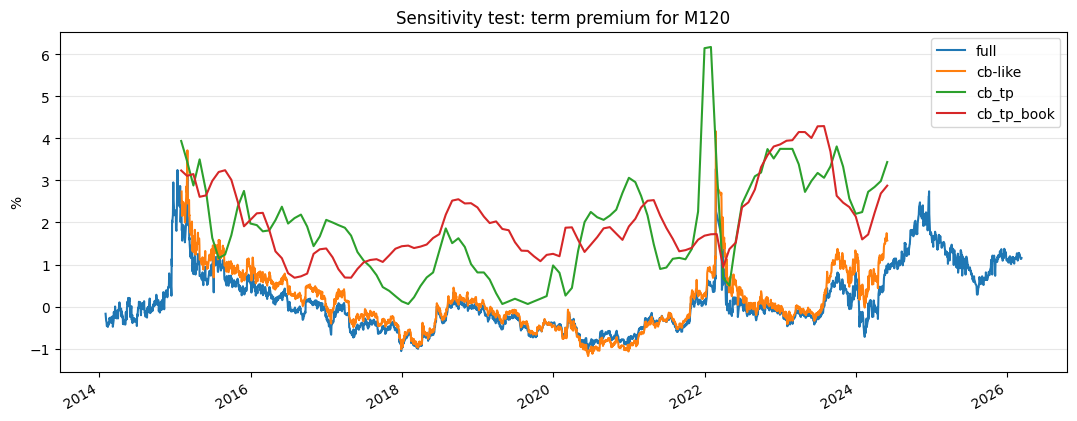

In [35]:
ax = tp_compare.plot(figsize=(13, 5))
plt.plot(cb_tp, label='cb_tp')
plt.plot(cb_tp_book, label='cb_tp_book')
ax.set_title(f"Sensitivity test: term premium for M{SENS_TENOR:03d}")
ax.set_ylabel("%")
ax.set_xlabel("")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
plt.show()
